# 🧠 CELL 1 — Imports  

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

from aegis.loaders.unsw_loader import UNSWNB15Loader
from aegis.loaders.cicids_loader import CICIDS2017Loader

from aegis.preprocessing.preprocessor import Preprocessor
from aegis.models.baselines.reference_model import ReferenceModel


# 🧠 CELL 2 — CONFIG

In [15]:
SCHEMA = "aegis/schema/universal_schema_v1.yaml"

UNSW_CONTRACT = "aegis/data/contracts/unsw_nb15.json"
CICIDS_CONTRACT = "aegis/data/contracts/cicids2017.json"

UNSW_PARQUET = "aegis/data/processed/unsw_nb15.parquet"
CICIDS_PARQUET = "aegis/data/processed/cicids_merged.parquet"

categorical = ["protocol"]
numeric = ["flow_duration", "src_bytes", "dst_bytes"]


In [16]:
import os

print("CWD:", os.getcwd())
print("Schema exists:", os.path.exists(SCHEMA))


CWD: c:\College-Work\Projects\AEGIS-XAI-NIDS
Schema exists: True


## LOAD DATASET

In [17]:
loader = UNSWNB15Loader(SCHEMA, UNSW_CONTRACT)
df = loader.load(UNSW_PARQUET)
df.head()

# loader = CICIDS2017Loader(SCHEMA, CICIDS_CONTRACT)
# df = loader.load(CICIDS_PARQUET)
# df.head()



,flow_duration,src_bytes,dst_bytes,protocol,label
0,0.000011,496,0,unknown,0
1,0.000008,1762,0,unknown,0
2,0.000005,1068,0,unknown,0
3,0.000006,900,0,unknown,0
4,0.000010,2126,0,unknown,0


# 🧠 CELL 3 — INIT PREPROCESSOR + MODEL

In [18]:
pp = Preprocessor(
    categorical_features=categorical,
    numeric_features=numeric
)

model = ReferenceModel(preprocessor=pp)


# 🧠 CELL 4 — TRAIN + EVALUATE

In [19]:
model.fit(df)
metrics = model.evaluate(df)

metrics["f1"]

0.9510011912190142

# 🧠 CELL 5 — SAVE METRICS

In [20]:
model.save_metrics(
    dataset_name="UNSWNB15",
    metrics=metrics
)

# model.save_metrics(
#     dataset_name="CICIDS2017",
#     metrics=metrics
# )

# 🧠 CELL 6 — CONFUSION MATRIX — VISUAL

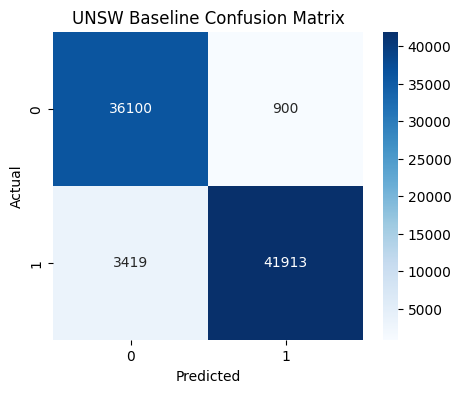

In [ ]:
X_t = model.preprocessor.transform(df)
y_true = df["label"]
y_pred = model.model.predict(X_t)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("UNSW Baseline Confusion Matrix")
plt.show()

# X_t = model.preprocessor.transform(df)
# y_true = df["label"]
# y_pred = model.model.predict(X_t)

# cm = confusion_matrix(y_true, y_pred)

# plt.figure(figsize=(5,4))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("CICIDS Baseline Confusion Matrix")
# plt.show()

In [22]:
from aegis.models.baselines.lightgbm_model import LightGBMBaseline

pp_lgbm = Preprocessor(
    categorical_features=categorical,
    numeric_features=numeric
)

lgbm_model = LightGBMBaseline(preprocessor=pp_lgbm)

lgbm_model.fit(df)
lgbm_metrics = lgbm_model.evaluate(df)

lgbm_metrics["f1"]


[LightGBM] [Info] Number of positive: 45332, number of negative: 37000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001074 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 82332, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.550600 -> initscore=0.203095
[LightGBM] [Info] Start training from score 0.203095


c:\College-Work\Projects\AEGIS-XAI-NIDS\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9374477034758814

In [23]:
print("RandomForest F1 :", metrics["f1"])
print("LightGBM F1     :", lgbm_metrics["f1"])


RandomForest F1 : 0.9510011912190142
LightGBM F1     : 0.9374477034758814


In [25]:
lgbm_model.save_metrics(
    dataset_name="UNSWNB15",
    metrics=lgbm_metrics
)


# lgbm_model.save_metrics(
#     dataset_name="CICIDS2017",
#     metrics=lgbm_metrics
# )
